In [1]:
from util import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

**Data**

In [2]:
np.random.seed(2025)
n_points = 51


noise = 0.01 * np.random.randn(n_points,1)
x = np.linspace(-1, 1, n_points).reshape(-1,1)
y = Runge(x) + noise

**Plotting GD method performance against polynomial degree**

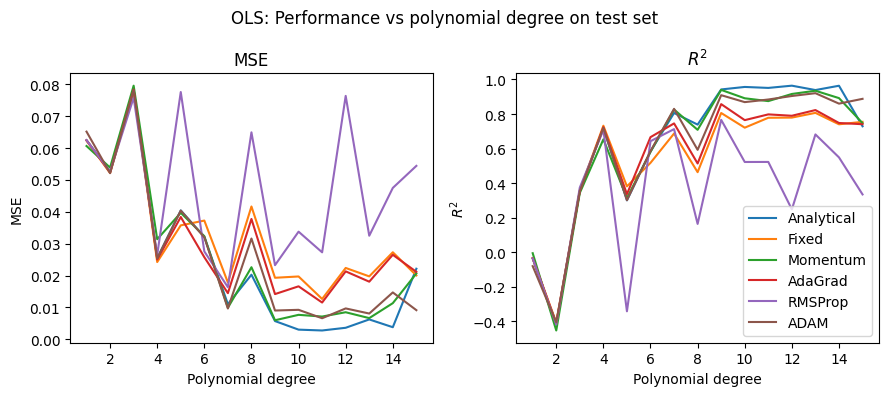

In [3]:
learning_rate = 0.05
l = 1e-4
maxdegree = 15

degrees = np.arange(1,maxdegree + 1)
# Analytical, Fixed, Momentum, AdaGrad, RMSProp, ADAM
ols_mses = []
ols_r2s = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    ols_mses_degree = []
    ols_r2s_degree = []

    # Plain OLS
    theta_OLS = OLS(X_train_s, y_train)
    OLS_predictions = X_test_s @ theta_OLS + y_offset
    ols_r2s_degree.append(r2_score(y_test, OLS_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, OLS_predictions))

    # Gradient descent solver
    OLS_grad_descent_solver = gradient_descent(X_train_s, y_train, OLS_Gradient, learning_rate)
    theta_grad_descent = OLS_grad_descent_solver.gradient_descent()
    grad_descent_predictions = X_test_s @ theta_grad_descent + y_offset
    ols_r2s_degree.append(r2_score(y_test, grad_descent_predictions))
    ols_mses_degree.append(mean_squared_error(y_test,   grad_descent_predictions))

    # Grad descent + momentum
    theta_momentum = OLS_grad_descent_solver.momentum(alpha = 0.995)
    momentum_predictions = X_test_s @ theta_momentum + y_offset
    ols_r2s_degree.append(r2_score(y_test, momentum_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, momentum_predictions))

    # Grad descent + AdaGrad
    theta_adagrad = OLS_grad_descent_solver.AdaGrad()
    adagrad_predictions = X_test_s @ theta_adagrad + y_offset
    ols_r2s_degree.append(r2_score(y_test, adagrad_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, adagrad_predictions))

    # Grad descent + RMSProp
    theta_rmsprop = OLS_grad_descent_solver.RMSProp(rho = 0.9)
    rmsprop_predictions = X_test_s @ theta_rmsprop + y_offset
    ols_r2s_degree.append(r2_score(y_test,rmsprop_predictions))
    ols_mses_degree.append(mean_squared_error(y_test, rmsprop_predictions))

    # Grad descent + ADAM
    theta_adam = OLS_grad_descent_solver.ADAM(rho1 = 0.9, rho2 = 0.999)
    adam_predictions = X_test_s @ theta_adam + y_offset
    ols_r2s_degree.append(r2_score(y_test, adam_predictions))   
    ols_mses_degree.append(mean_squared_error(y_test, adam_predictions))

    ols_mses.append(ols_mses_degree)
    ols_r2s.append(ols_r2s_degree)

# The columns of the matrices correspond to the different methods
# Rows correspond to the polynomial degrees
ols_mses = np.array(ols_mses)
ols_r2s = np.array(ols_r2s)

methods = ["Analytical", "Fixed", "Momentum", "AdaGrad", "RMSProp", "ADAM"]

fig, ax = plt.subplots(1,2, figsize = (9,4))
fig.suptitle("OLS: Performance vs polynomial degree on test set")

ax[0].set_title("MSE")
ax[1].set_title(r"$R^2$")
ax[0].set_xlabel("Polynomial degree")
ax[1].set_xlabel("Polynomial degree")
ax[0].set_ylabel("MSE")
ax[1].set_ylabel(r"$R^2$")

for i, method in enumerate(methods):
    ax[0].plot(degrees, ols_mses[:,i], label = method)
    ax[1].plot(degrees, ols_r2s[:,i], label = method)

ax[1].legend()
fig.tight_layout()

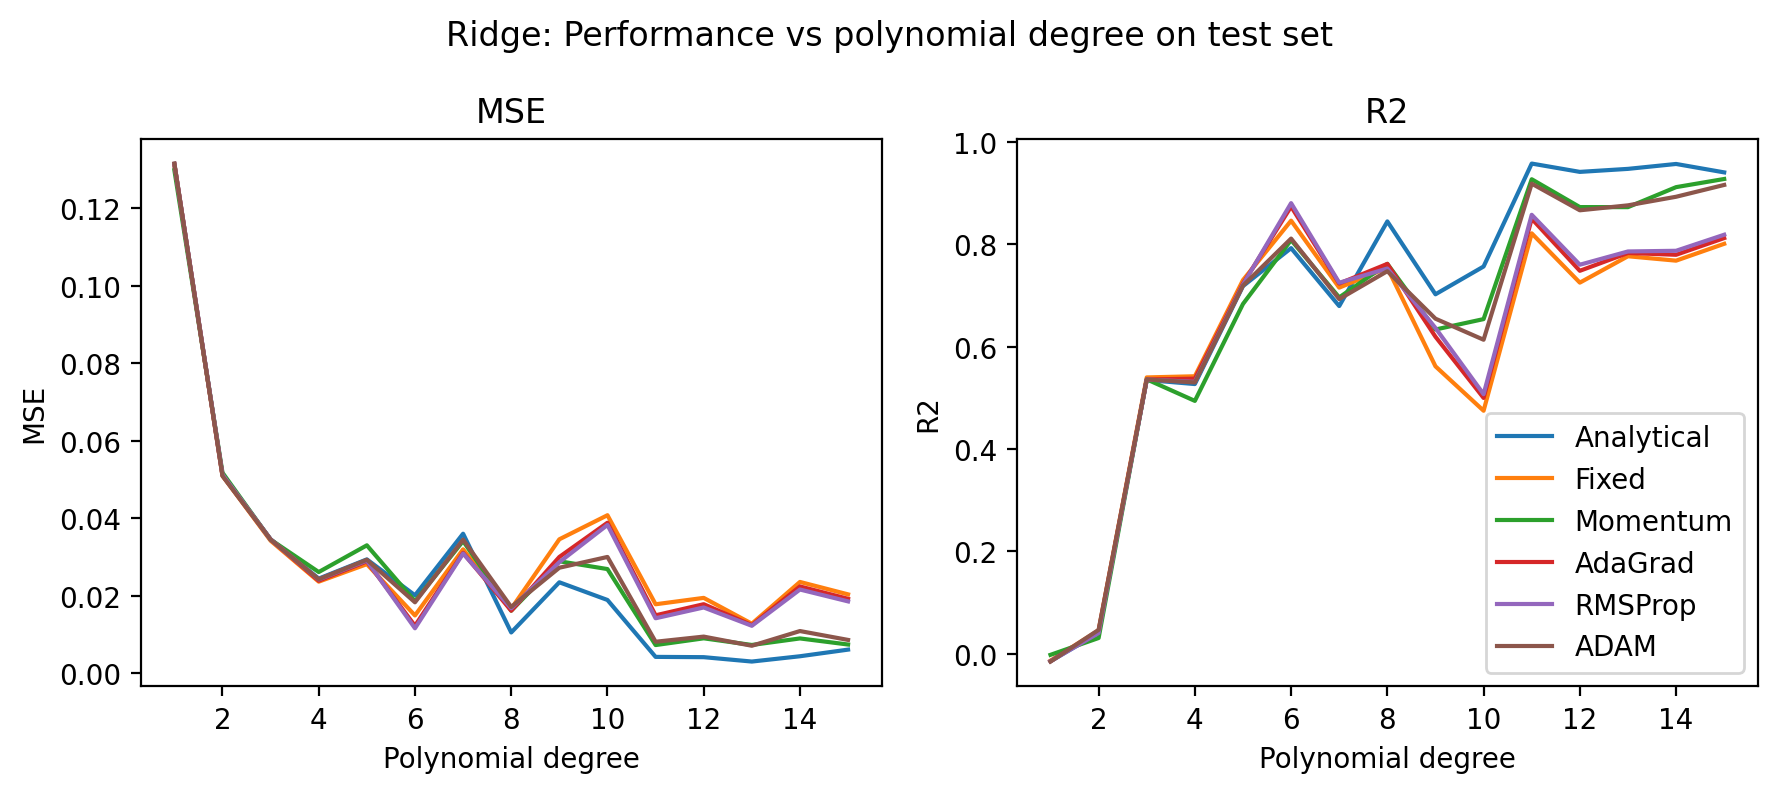

In [4]:
np.random.seed(2025)

learning_rate = 0.05
l=1e-4
maxdegree = 15
lambdas = np.logspace(-7,0,8)

degrees = np.arange(1,maxdegree + 1)
# Analytical, Fixed, Momentum, AdaGrad, RMSProp, ADAM
Ridge_mses = []
Ridge_r2s = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    Ridge_mses_degree = []
    Ridge_r2s_degree = []

    # Plain Ridge
    theta_Ridge = Ridge(X_train_s, y_train, l)
    Ridge_predictions = X_test_s @ theta_Ridge + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, Ridge_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test, Ridge_predictions))

    # Gradient descent solver
    Ridge_grad_descent_solver = gradient_descent(X_train_s, y_train, Ridge_Gradient, learning_rate, hyperparameter = l)
    theta_grad_descent = Ridge_grad_descent_solver.gradient_descent()
    grad_descent_predictions = X_test_s @ theta_grad_descent + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, grad_descent_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test,   grad_descent_predictions))

    # Grad descent + momentum
    theta_momentum = Ridge_grad_descent_solver.momentum(alpha = 0.995)
    momentum_predictions = X_test_s @ theta_momentum + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, momentum_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test, momentum_predictions))

    # Grad descent + AdaGrad
    theta_adagrad = Ridge_grad_descent_solver.AdaGrad()
    adagrad_predictions = X_test_s @ theta_adagrad + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, adagrad_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test, adagrad_predictions))

    # Grad descent + RMSProp
    theta_rmsprop = Ridge_grad_descent_solver.RMSProp(rho = 0.999)
    rmsprop_predictions = X_test_s @ theta_rmsprop + y_offset
    Ridge_r2s_degree.append(r2_score(y_test,rmsprop_predictions))
    Ridge_mses_degree.append(mean_squared_error(y_test, rmsprop_predictions))

    # Grad descent + ADAM
    theta_adam = Ridge_grad_descent_solver.ADAM(rho1 = 0.9, rho2 = 0.999)
    adam_predictions = X_test_s @ theta_adam + y_offset
    Ridge_r2s_degree.append(r2_score(y_test, adam_predictions))   
    Ridge_mses_degree.append(mean_squared_error(y_test, adam_predictions))

    Ridge_mses.append(Ridge_mses_degree)
    Ridge_r2s.append(Ridge_r2s_degree)


# The columns of the matrices correspond to the different methods
# Rows correspond to the polynomial degrees
Ridge_mses = np.array(Ridge_mses)
Ridge_r2s = np.array(Ridge_r2s)

methods = ["Analytical", "Fixed", "Momentum", "AdaGrad", "RMSProp", "ADAM"]

fig, ax = plt.subplots(1,2, figsize = (9,4), dpi = 200)
fig.suptitle("Ridge: Performance vs polynomial degree on test set")

ax[0].set_title("MSE")
ax[1].set_title("R2")
ax[0].set_xlabel("Polynomial degree")
ax[1].set_xlabel("Polynomial degree")
ax[0].set_ylabel("MSE")
ax[1].set_ylabel("R2")

for i, method in enumerate(methods):
    ax[0].plot(degrees, Ridge_mses[:,i], label = method)
    ax[1].plot(degrees, Ridge_r2s[:,i], label = method)
    
ax[1].legend()
fig.tight_layout()

**Plotting RMSProp only, with hyperparameters and polynomial degrees**

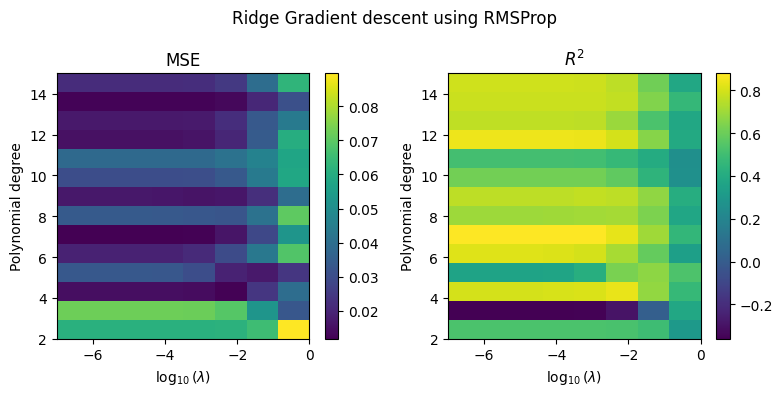

In [5]:
np.random.seed(2025)

learning_rate = 0.05

maxdegree = 15
n_lambdas = 8

lambdas = np.logspace(-7, 0, n_lambdas)
degrees = np.arange(2, maxdegree+1, 1)
mses = []
r2s = []

for degree in degrees:
    X = PolynomialFeatures(degree = degree).fit_transform(x)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    # Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    y_offset = np.mean(y_test)

    MSE = []
    r2 = []
    for l in lambdas:
        # Gradient descent solver
        beta = gradient_descent(X_train_s, y_train, Ridge_Gradient, learning_rate, hyperparameter = l).RMSProp(rho = 0.999)
        
        predict_test = X_test_s @ beta + y_offset
        MSE.append(mean_squared_error(y_test, predict_test))
        r2.append(r2_score(y_test, predict_test))
    mses.append(MSE)
    r2s.append(r2)

fig, axes = plt.subplots(1, 2, figsize = (8, 4) )
fig.suptitle("Ridge Gradient descent using RMSProp")
ax = axes[0]

# Mean Squared Error plot
ax.set_title("MSE")
im = ax.imshow(mses, aspect="auto", extent=(np.log10(lambdas.min()), np.log10(lambdas.max()), degrees.min(), degrees.max()), origin="lower")
ax.set_ylabel("Polynomial degree")
ax.set_xlabel(r"$\log_{10}(\lambda)$")
fig.colorbar(im, ax = ax)

# R2 plot
ax = axes[1]
ax.set_title(r"$R^2$")
im = ax.imshow(r2s, aspect="auto", extent=(np.log10(lambdas.min()), np.log10(lambdas.max()), degrees.min(), degrees.max()), origin="lower")
ax.set_xlabel(r"$\log_{10}(\lambda)$")
ax.set_ylabel("Polynomial degree")
fig.colorbar(im, ax = ax)

fig.tight_layout()